# 🛰️ Notebook 2: Introduction to Data Processing
This notebook introduces the **Data Processing** using `odc-stac` 

By the end of this notebook, you will:
- Understand how to do calculations using `odc-stac`
- How to download Imagery using `rioxarray`

---

Let's start by searching for 3 months data over Auckland with cloud cover less than 10%

In [1]:
from pystac_client import Client

# Connect to a public catalog
catalog = Client.open('https://earth-search.aws.element84.com/v1')

# Intersects
area_of_interest =  {
        "coordinates": [
          [
            [
              73.66059124581909,
              20.04371590757539
            ],
            [
              73.66059124581909,
              19.981360740605894
            ],
            [
              73.72993716518059,
              19.981360740605894
            ],
            [
              73.72993716518059,
              20.04371590757539
            ],
            [
              73.66059124581909,
              20.04371590757539
            ]
          ]
        ],
        "type": "Polygon"
      }

time_range = "2024-01-01/2024-03-31"

search = catalog.search(
    collections=["sentinel-2-l2a"], 
    query={"eo:cloud_cover": {"lt": 10}},
    intersects=area_of_interest, 
    datetime=time_range
)
items = list(search.get_items())
print(f'Found {len(items)} items')

/opt/homebrew/Caskroom/miniconda/base/envs/stac/lib/python3.12/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Found 28 items


Let's load this data using `odc-stac` so we can inspect the values

In [2]:
from odc.stac import load
print('odc.stac available')


odc.stac available


In [20]:
ds = load(items, 
          groupby='solar_day', # Controls what items are placed in similar pixel plane
          resolution=10,
          chunks={'x':1024,'y':1024}, # Optional : Helpful to divide data in chunks for calculation
          bands=['red','green','blue','nir'],  # Optional : It helps in loading only bands that we want 
          geopolygon=area_of_interest,
          )
ds

<xarray.Dataset> Size: 106MB
Dimensions:      (y: 697, x: 732, time: 26)
Coordinates:
  * y            (y) float64 6kB 2.217e+06 2.217e+06 ... 2.21e+06 2.21e+06
  * x            (x) float64 6kB 3.599e+05 3.599e+05 ... 3.672e+05 3.672e+05
  * time         (time) datetime64[ns] 208B 2024-01-02T05:53:23.226000 ... 20...
    spatial_ref  int32 4B 32643
Data variables:
    red          (time, y, x) uint16 27MB dask.array<chunksize=(1, 697, 732), meta=np.ndarray>
    green        (time, y, x) uint16 27MB dask.array<chunksize=(1, 697, 732), meta=np.ndarray>
    blue         (time, y, x) uint16 27MB dask.array<chunksize=(1, 697, 732), meta=np.ndarray>
    nir          (time, y, x) uint16 27MB dask.array<chunksize=(1, 697, 732), meta=np.ndarray>

In [21]:
# Inspecting single element
item_0 = ds.isel(time=0)
item_0

<xarray.Dataset> Size: 4MB
Dimensions:      (y: 697, x: 732)
Coordinates:
  * y            (y) float64 6kB 2.217e+06 2.217e+06 ... 2.21e+06 2.21e+06
  * x            (x) float64 6kB 3.599e+05 3.599e+05 ... 3.672e+05 3.672e+05
    spatial_ref  int32 4B 32643
    time         datetime64[ns] 8B 2024-01-02T05:53:23.226000
Data variables:
    red          (y, x) uint16 1MB dask.array<chunksize=(697, 732), meta=np.ndarray>
    green        (y, x) uint16 1MB dask.array<chunksize=(697, 732), meta=np.ndarray>
    blue         (y, x) uint16 1MB dask.array<chunksize=(697, 732), meta=np.ndarray>
    nir          (y, x) uint16 1MB dask.array<chunksize=(697, 732), meta=np.ndarray>

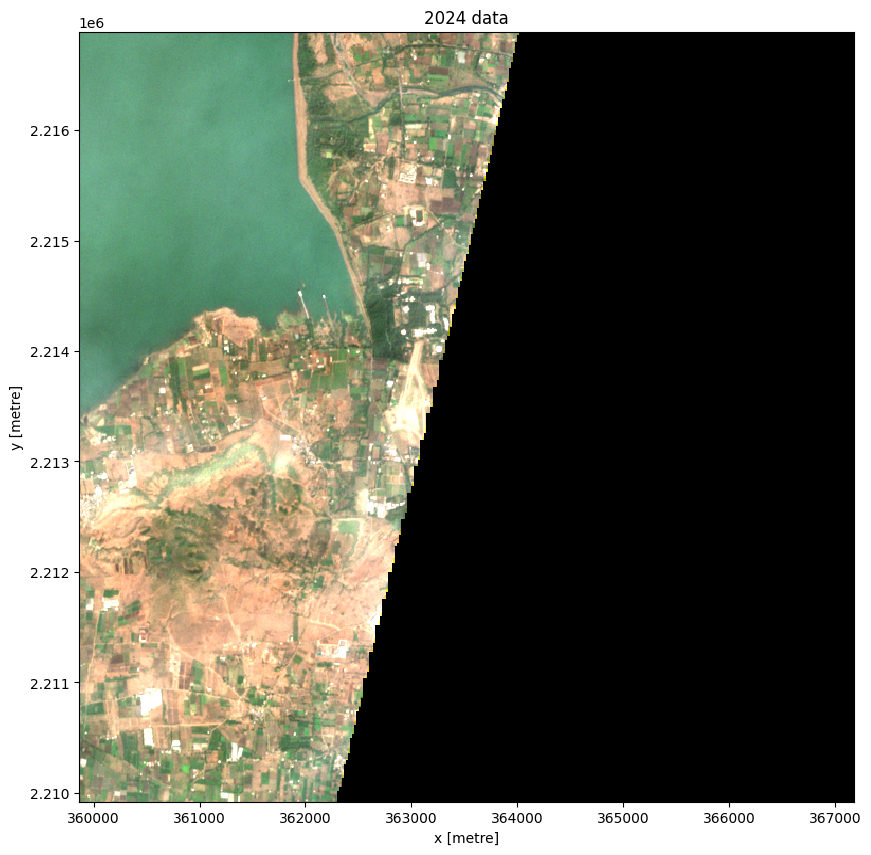

In [22]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
item_0[["red",  "green","blue"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("2024 data");

Since the image is not covering our entire AOI, we can make mosaic of all images

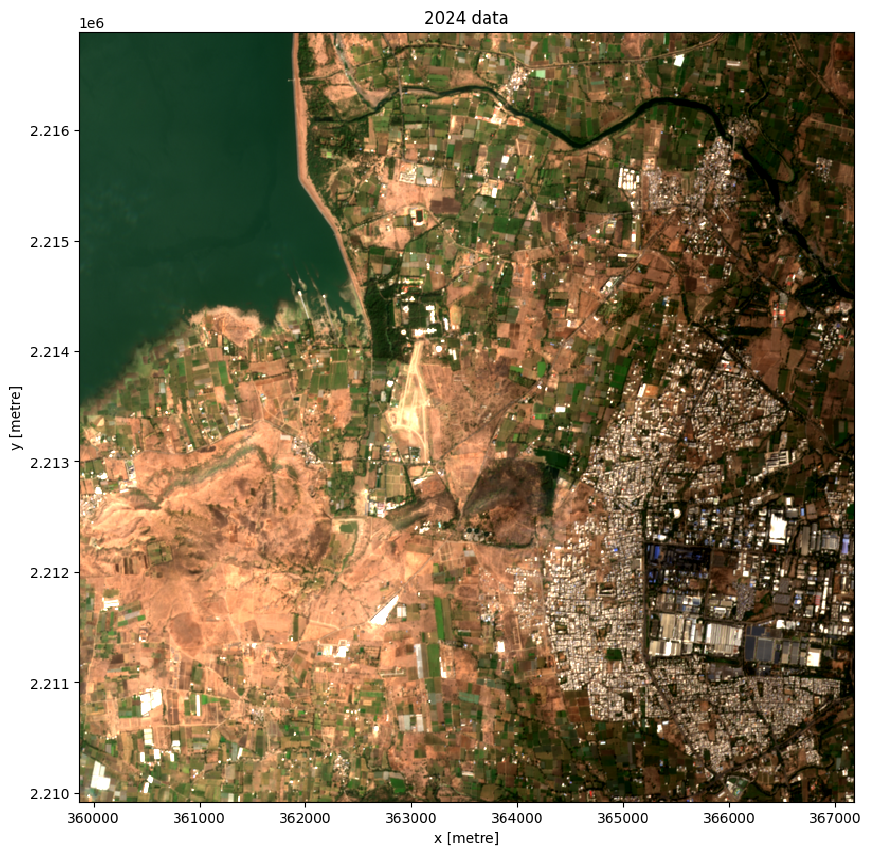

In [25]:
ds_mosaic = ds.mean(dim='time')
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
ds_mosaic[["red",  "green","blue"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("2024 data mosaic");

Export True color as TIFF using `rioxarray`

In [ ]:
import rioxarray
ds_mosaic[["red",  "green","blue"]].rio.to_raster('true_color.tif')

## Numerical calculations

Let's start by calculating NDVI

In [29]:
# NDVI = (NIR - Red) / (NIR + Red)
ndvi = (ds_mosaic.nir - ds_mosaic.red) / (ds_mosaic.nir + ds_mosaic.red)
ndvi.name = 'NDVI'

ndvi

<xarray.DataArray 'NDVI' (y: 697, x: 732)> Size: 4MB
dask.array<truediv, shape=(697, 732), dtype=float64, chunksize=(697, 732), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 6kB 2.217e+06 2.217e+06 ... 2.21e+06 2.21e+06
  * x            (x) float64 6kB 3.599e+05 3.599e+05 ... 3.672e+05 3.672e+05
    spatial_ref  int32 4B 32643

Get Statistical values from it

In [38]:
computed = ndvi.compute() 
computed.mean(), computed.min(), computed.max()

(<xarray.DataArray 'NDVI' ()> Size: 8B
 array(0.27734136)
 Coordinates:
     spatial_ref  int32 4B 32643,
 <xarray.DataArray 'NDVI' ()> Size: 8B
 array(-0.35221042)
 Coordinates:
     spatial_ref  int32 4B 32643,
 <xarray.DataArray 'NDVI' ()> Size: 8B
 array(0.87441656)
 Coordinates:
     spatial_ref  int32 4B 32643)

Plot NDVI values from it

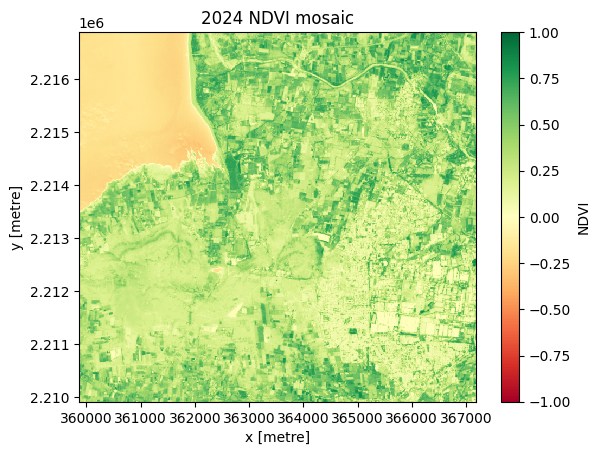

In [37]:
fig, ax = plt.subplots()
ndvi.plot.imshow( cmap="RdYlGn",
    vmin=-1, vmax=1,robust=True, ax=ax)
ax.set_title("2024 NDVI mosaic");


Export NDVI raster

In [39]:
ndvi.rio.to_raster('ndvi.tif')